<a href="https://colab.research.google.com/github/heewonLEE2/Paper-Implementations/blob/main/RL/ACER_Implement.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ==========================================
# [ACER] Cell 1: Setup & Hyperparameters
# ==========================================
!pip install gymnasium -q

import gymnasium as gym
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
from collections import deque
import random
import copy
import matplotlib.pyplot as plt

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

# --- Hyperparameters ---
GAMMA         = 0.99    # 할인율
LR_ACTOR      = 3e-4    # Actor 학습률
LR_CRITIC     = 1e-3    # Critic 학습률 (Actor보다 높게 — value 수렴을 빠르게)
BUFFER_SIZE   = 5000    # Replay buffer 용량 (에피소드 단위)
REPLAY_RATIO  = 4       # On-policy 1회당 off-policy 몇 회 학습할지
C_RETRACE     = 1.0     # Retrace truncation threshold
C_BAR         = 10.0    # Policy gradient IS truncation threshold
DELTA         = 1.0     # Trust region constraint (KL bound)
EMA_ALPHA     = 0.995   # Average policy EMA 계수
MAX_EPISODES  = 1500
HIDDEN_DIM    = 128

Device: cpu


In [ ]:
# ==========================================
# [ACER] Cell 2: Episode Replay Buffer
# ==========================================
# ACER의 핵심: trajectory 단위로 저장하며,
# 각 transition에 behavior policy μ(a|s)를 함께 저장한다.
# → 나중에 off-policy 학습 시 importance ratio 계산에 필요

class EpisodeReplayBuffer:
    def __init__(self, capacity):
        self.buffer = deque(maxlen=capacity)

    def push(self, episode):
        """
        episode: dict with keys
          'states':         FloatTensor [T, state_dim]
          'actions':        LongTensor  [T]
          'rewards':        FloatTensor [T]
          'dones':          FloatTensor [T]   (마지막 step만 1.0)
          'behavior_probs': FloatTensor [T, num_actions]  ← μ(·|s)
        """
        self.buffer.append(episode)

    def sample(self):
        return random.choice(self.buffer)

    def __len__(self):
        return len(self.buffer)

In [ ]:
# ==========================================
# [ACER] Cell 3: Actor & Critic Networks
# ==========================================
# Actor: s → π(a|s)  (softmax 확률 분포)
# Critic: s → Q(s,a) for ALL actions
#
# ⚠️ 일반 A2C는 V(s)를 출력하지만, ACER는 Q(s,a)를 출력한다.
# 이유: bias correction에서 모든 action에 대한 Q값이 필요하고,
#       V(s) = Σ_a π(a|s)·Q(s,a) 로 유도하기 때문.

class Actor(nn.Module):
    def __init__(self, state_dim, action_dim, hidden=HIDDEN_DIM):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(state_dim, hidden),
            nn.ReLU(),
            nn.Linear(hidden, hidden),
            nn.ReLU(),
            nn.Linear(hidden, action_dim),
        )

    def forward(self, x):
        logits = self.net(x)
        # 수치 안정성을 위해 logits에서 max를 빼줌
        probs = F.softmax(logits - logits.max(dim=-1, keepdim=True).values, dim=-1)
        return probs


class Critic(nn.Module):
    def __init__(self, state_dim, action_dim, hidden=HIDDEN_DIM):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(state_dim, hidden),
            nn.ReLU(),
            nn.Linear(hidden, hidden),
            nn.ReLU(),
            nn.Linear(hidden, action_dim),  # Q(s,a) for each action
        )

    def forward(self, x):
        return self.net(x)

In [ ]:
# ==========================================
# [ACER] Cell 4: Retrace(λ) — Off-policy 보정된 Q-target
# ==========================================
# Off-policy 데이터에서 Q-value를 추정할 때,
# 단순 importance sampling은 분산이 폭발한다.
# Retrace는 importance weight를 min(c, ρ)로 clipping하여
# 분산을 줄이면서도 unbiased target을 제공한다.
#
# 수식 (backward 재귀):
#   Q^ret_t = r_t + γ · [c̄_{t+1} · (Q^ret_{t+1} − Q(s_{t+1},a_{t+1})) + V(s_{t+1})]
#   V(s) = Σ_a π(a|s) · Q(s,a)
#
# 마지막 step (terminal): Q^ret_T = r_T (bootstrap 없음)

def compute_retrace(rewards, dones, q_values, pi, mu_probs, actions,
                    gamma=GAMMA, c=C_RETRACE):
    """
    Returns (모두 detached):
      q_ret:    [T]              - Retrace target
      rho_a:    [T]              - taken action의 importance ratio
      rho_all:  [T, num_actions] - 모든 action의 importance ratio
      v:        [T]              - V(s) = Σ π·Q
    """
    T = len(rewards)

    with torch.no_grad():
        v = (pi * q_values).sum(dim=-1)                                # [T]
        q_a = q_values.gather(1, actions.unsqueeze(1)).squeeze(1)      # [T]

        # Importance ratios
        rho_all = pi / (mu_probs + 1e-8)                              # [T, A]
        pi_a  = pi.gather(1, actions.unsqueeze(1)).squeeze(1)
        mu_a  = mu_probs.gather(1, actions.unsqueeze(1)).squeeze(1)
        rho_a = pi_a / (mu_a + 1e-8)                                  # [T]

        c_bar = torch.clamp(rho_a, max=c)                             # [T]

        # Backward 재귀
        q_ret = torch.zeros(T, device=rewards.device)
        q_ret[-1] = rewards[-1]   # terminal step

        for t in range(T - 2, -1, -1):
            # dones[t]==1 이면 terminal → bootstrap 없음
            # 우리 에피소드에서는 마지막 step만 done=1이지만, 안전하게 처리
            q_ret[t] = rewards[t] + gamma * (1.0 - dones[t]) * (
                c_bar[t + 1] * (q_ret[t + 1] - q_a[t + 1]) + v[t + 1]
            )

    return q_ret, rho_a, rho_all, v

In [ ]:
# ==========================================
# [ACER] Cell 5: ACER Update — 4가지 핵심 요소 결합
# ==========================================
#
# 하나의 trajectory에 대해:
#  ① Experience Replay: on-policy든 off-policy든 동일 함수로 학습
#  ② Retrace(λ): off-policy 보정된 Q-target으로 Critic 학습
#  ③ Truncated IS + Bias Correction: Actor policy gradient
#  ④ Trust Region: average policy 와의 KL constraint → gradient projection
#
# Trust Region 구현 핵심:
#   1. actor loss의 gradient g를 π(분포) 공간에서 계산
#   2. KL(π_avg || π)의 gradient k를 π 공간에서 계산
#   3. g를 KL constraint 안쪽으로 projection:
#      z = g − max(0, (k·g − δ) / (k·k)) · k
#   4. projected gradient z를 network parameter로 backprop

def acer_update(episode, actor, critic, avg_actor,
                actor_opt, critic_opt,
                gamma=GAMMA, c_bar_trunc=C_BAR, delta=DELTA):
    """한 episode(trajectory)에 대한 ACER update. on/off-policy 공용."""

    states = episode['states'].to(device)       # [T, S]
    actions = episode['actions'].to(device)     # [T]
    rewards = episode['rewards'].to(device)     # [T]
    dones = episode['dones'].to(device)         # [T]
    mu_probs = episode['behavior_probs'].to(device)  # [T, A]

    # ─── Forward ───
    q = critic(states)                           # [T, A]

    # Retrace targets (all detached)
    with torch.no_grad():
        pi_detached = actor(states)
    q_ret, rho_a, rho_all, v = compute_retrace(
        rewards, dones, q.detach(), pi_detached, mu_probs, actions, gamma
    )

    # ═══════════════════════════════════════
    # ② CRITIC UPDATE — MSE(Q(s,a_t), Q^ret)
    # ═══════════════════════════════════════
    q_taken = q.gather(1, actions.unsqueeze(1)).squeeze(1)  # [T]
    critic_loss = F.mse_loss(q_taken, q_ret)

    critic_opt.zero_grad()
    critic_loss.backward()
    nn.utils.clip_grad_norm_(critic.parameters(), 10.0)
    critic_opt.step()

    # ═══════════════════════════════════════
    # ③④ ACTOR UPDATE — Truncated IS + Bias Correction + Trust Region
    # ═══════════════════════════════════════
    pi = actor(states)        # [T, A] — 새 forward (critic graph 소비됨)
    pi.retain_grad()          # π 공간에서 gradient를 뽑기 위해

    with torch.no_grad():
        pi_avg = avg_actor(states)  # [T, A]
        q_new = critic(states)      # [T, A]
        v_new = (pi.detach() * q_new).sum(dim=-1)          # [T]
        rho_new_all = pi.detach() / (mu_probs + 1e-8)      # [T, A]
        rho_new_a = rho_new_all.gather(1, actions.unsqueeze(1)).squeeze(1)  # [T]

    # ── ③-1: Truncated Importance Sampling term ──
    # g_trunc = min(c̄, ρ) · (Q^ret − V) · log π(a_t|s_t)
    rho_bar = torch.clamp(rho_new_a, max=c_bar_trunc).detach()  # [T]
    advantage = (q_ret - v_new).detach()                          # [T]
    pi_a = pi.gather(1, actions.unsqueeze(1)).squeeze(1)          # [T]
    log_pi_a = torch.log(pi_a + 1e-8)

    trunc_gain = (rho_bar * advantage * log_pi_a).sum()

    # ── ③-2: Bias Correction term ──
    # Σ_a [1 − c̄/ρ(a)]₊ · π(a|s) · (Q(s,a) − V(s))
    # → truncation으로 잘려나간 부분의 bias를 보정
    bc_weight = torch.clamp(
        1.0 - c_bar_trunc / (rho_new_all + 1e-8), min=0.0
    ).detach()                                                    # [T, A]
    q_adv_all = (q_new - v_new.unsqueeze(1)).detach()             # [T, A]
    bc_gain = (bc_weight * pi * q_adv_all).sum()

    actor_gain = trunc_gain + bc_gain  # 최대화 대상

    # ── ④: Trust Region Projection ──
    # Step 1: actor gain의 gradient (π 공간)
    g = torch.autograd.grad(actor_gain, pi, retain_graph=True)[0]  # [T, A]

    # Step 2: KL(π_avg || π)의 gradient (π 공간)
    kl = (pi_avg * (torch.log(pi_avg + 1e-8) - torch.log(pi + 1e-8))).sum()
    k = torch.autograd.grad(kl, pi, retain_graph=True)[0]         # [T, A]

    # Step 3: timestep별 projection
    #   z = g − max(0, (k·g − δ)/(k·k)) · k
    k_dot_g = (k * g).sum(dim=-1)       # [T]
    k_dot_k = (k * k).sum(dim=-1)       # [T]
    adj = torch.clamp((k_dot_g - delta) / (k_dot_k + 1e-10), min=0.0)  # [T]
    z = g - adj.unsqueeze(1) * k        # [T, A] — projected gradient

    # Step 4: projected gradient를 network parameter로 backprop
    # z는 ascent 방향 → optimizer는 minimize → -z를 전달
    actor_opt.zero_grad()
    pi.backward(gradient=-z)
    nn.utils.clip_grad_norm_(actor.parameters(), 10.0)
    actor_opt.step()

    # ═══════════════════════════════════════
    # Average Policy EMA Update
    # ═══════════════════════════════════════
    with torch.no_grad():
        for p_avg, p in zip(avg_actor.parameters(), actor.parameters()):
            p_avg.data.mul_(EMA_ALPHA).add_(p.data, alpha=1.0 - EMA_ALPHA)

    return {
        'critic_loss': critic_loss.item(),
        'actor_gain': actor_gain.item(),
        'kl': kl.item(),
        'mean_rho': rho_new_a.mean().item(),
    }

In [ ]:
# ==========================================
# [ACER] Cell 6: Episode Collection
# ==========================================

def collect_episode(env, actor):
    states, actions, rewards, dones, behavior_probs = [], [], [], [], []
    state, _ = env.reset()
    done = False

    while not done:
        s_tensor = torch.FloatTensor(state).unsqueeze(0).to(device)
        with torch.no_grad():
            pi = actor(s_tensor).squeeze(0)   # [A]

        action = torch.multinomial(pi, 1).item()
        next_state, reward, terminated, truncated, _ = env.step(action)
        done = terminated or truncated

        states.append(state)
        actions.append(action)
        rewards.append(reward)
        dones.append(float(done))
        behavior_probs.append(pi.cpu().numpy())

        state = next_state

    episode = {
        'states':         torch.FloatTensor(np.array(states)),
        'actions':        torch.LongTensor(actions),
        'rewards':        torch.FloatTensor(rewards),
        'dones':          torch.FloatTensor(dones),
        'behavior_probs': torch.FloatTensor(np.array(behavior_probs)),
    }
    return episode, sum(rewards)

In [ ]:
# ==========================================
# [ACER] Cell 7: Training Loop
# ==========================================
# 흐름: on-policy 수집 → 즉시 학습 → buffer 저장 → off-policy replay 학습

env = gym.make('CartPole-v1')
state_dim = env.observation_space.shape[0]   # 4
action_dim = env.action_space.n              # 2

# Networks
actor     = Actor(state_dim, action_dim).to(device)
critic    = Critic(state_dim, action_dim).to(device)
avg_actor = copy.deepcopy(actor)
for p in avg_actor.parameters():
    p.requires_grad = False   # EMA로만 업데이트

actor_opt  = torch.optim.Adam(actor.parameters(), lr=LR_ACTOR)
critic_opt = torch.optim.Adam(critic.parameters(), lr=LR_CRITIC)
buffer = EpisodeReplayBuffer(BUFFER_SIZE)

# Logging
reward_history = []
critic_losses  = []
kl_values      = []
rho_values     = []

for ep in range(MAX_EPISODES):
    # 1) On-policy episode 수집
    episode, ep_reward = collect_episode(env, actor)
    reward_history.append(ep_reward)

    # 2) On-policy ACER update
    info = acer_update(episode, actor, critic, avg_actor, actor_opt, critic_opt)

    # 3) Buffer에 저장
    buffer.push(episode)

    # 4) Off-policy replay updates (sample efficiency의 핵심!)
    if len(buffer) > 20:
        for _ in range(REPLAY_RATIO):
            replay_ep = buffer.sample()
            acer_update(replay_ep, actor, critic, avg_actor, actor_opt, critic_opt)

    # Logging
    critic_losses.append(info['critic_loss'])
    kl_values.append(info['kl'])
    rho_values.append(info['mean_rho'])

    if (ep + 1) % 50 == 0:
        avg_r = np.mean(reward_history[-50:])
        print(f"Ep {ep+1:4d} | Avg Reward(50): {avg_r:6.1f} | "
              f"Critic Loss: {info['critic_loss']:.4f} | "
              f"KL: {info['kl']:.4f} | ρ_mean: {info['mean_rho']:.2f}")

    # 조기 종료 (100 에피소드 평균 475 이상)
    if len(reward_history) >= 100 and np.mean(reward_history[-100:]) >= 475:
        print(f"\n✅ Solved at episode {ep+1}!")
        break

env.close()

Ep   50 | Avg Reward(50):   24.1 | Critic Loss: 248.8988 | KL: 1.5432 | ρ_mean: 1.00
Ep  100 | Avg Reward(50):   60.3 | Critic Loss: 1435.5796 | KL: 5.2778 | ρ_mean: 1.00
Ep  150 | Avg Reward(50):  144.5 | Critic Loss: 118.4093 | KL: 1.2722 | ρ_mean: 1.00
Ep  200 | Avg Reward(50):  242.8 | Critic Loss: 25.9733 | KL: 2.1696 | ρ_mean: 1.00
Ep  250 | Avg Reward(50):  374.2 | Critic Loss: 45.5751 | KL: 3.5591 | ρ_mean: 1.00
Ep  300 | Avg Reward(50):  384.4 | Critic Loss: 17.3111 | KL: 3.2373 | ρ_mean: 1.00
Ep  350 | Avg Reward(50):  410.0 | Critic Loss: 81.3629 | KL: 7.7023 | ρ_mean: 1.00
Ep  400 | Avg Reward(50):  455.3 | Critic Loss: 298.0164 | KL: 20.8913 | ρ_mean: 1.00

✅ Solved at episode 447!


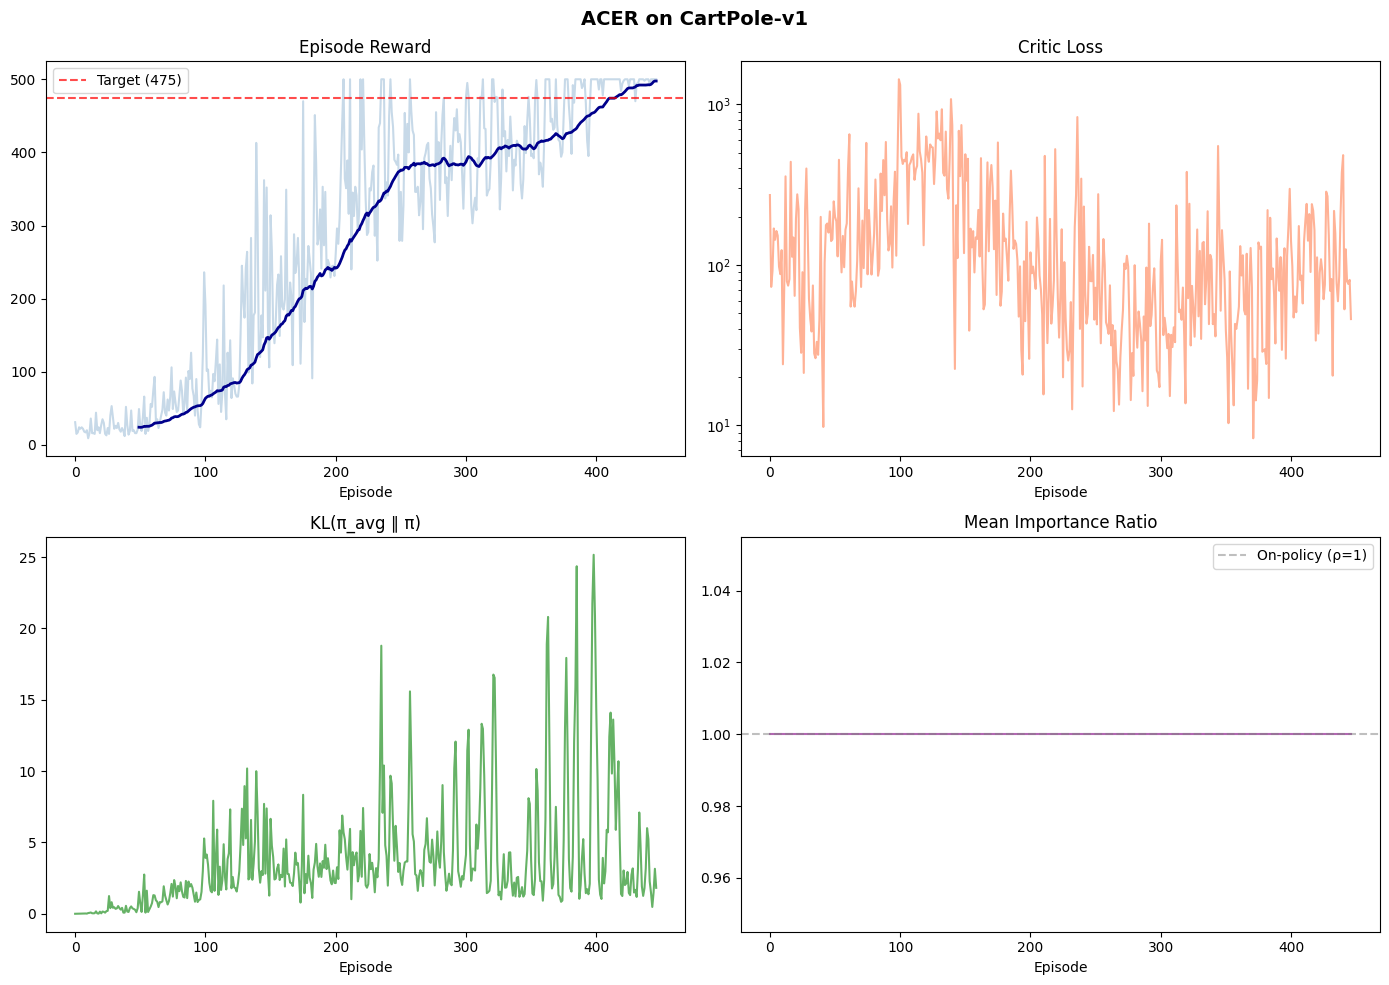

In [ ]:
# ==========================================
# [ACER] Cell 8: Training Visualization
# ==========================================

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# (1) Reward curve
axes[0,0].plot(reward_history, alpha=0.3, color='steelblue')
if len(reward_history) >= 50:
    ma = np.convolve(reward_history, np.ones(50)/50, mode='valid')
    axes[0,0].plot(range(49, len(reward_history)), ma, color='darkblue', lw=2)
axes[0,0].axhline(475, color='red', ls='--', alpha=0.7, label='Target (475)')
axes[0,0].set_title('Episode Reward')
axes[0,0].set_xlabel('Episode')
axes[0,0].legend()

# (2) Critic loss
axes[0,1].plot(critic_losses, color='coral', alpha=0.6)
axes[0,1].set_title('Critic Loss')
axes[0,1].set_xlabel('Episode')
axes[0,1].set_yscale('log')

# (3) KL divergence (trust region이 잘 작동하면 안정적)
axes[1,0].plot(kl_values, color='green', alpha=0.6)
axes[1,0].set_title('KL(π_avg ∥ π)')
axes[1,0].set_xlabel('Episode')

# (4) Importance ratio (off-policy 정도를 보여줌)
axes[1,1].plot(rho_values, color='purple', alpha=0.6)
axes[1,1].axhline(1.0, color='gray', ls='--', alpha=0.5, label='On-policy (ρ=1)')
axes[1,1].set_title('Mean Importance Ratio')
axes[1,1].set_xlabel('Episode')
axes[1,1].legend()

plt.suptitle('ACER on CartPole-v1', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()